# Tutorial 4 Task Solution¶

## Generating Synthetic Data

Lets create a synthetic dataset as below

$f(x) = \beta_0 + \beta_1 x + \beta_2 x^2 $

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Initialise RNG, so we get same result everytime
np.random.seed(0)

# Number of training points
m = 50

x = np.linspace(0.0, 1.0, m)

# Function coefficients/parameters
beta0 = 4
beta1 = 1.5
beta2 = 3.2
 
# f values from 2nd order polynomial
f = beta0 + beta1 * x + beta2 * np.power(x,2)  

# Generate noisy sample from population
sigma2 = 0.1
y = f + np.random.normal(0, np.sqrt(sigma2), m)

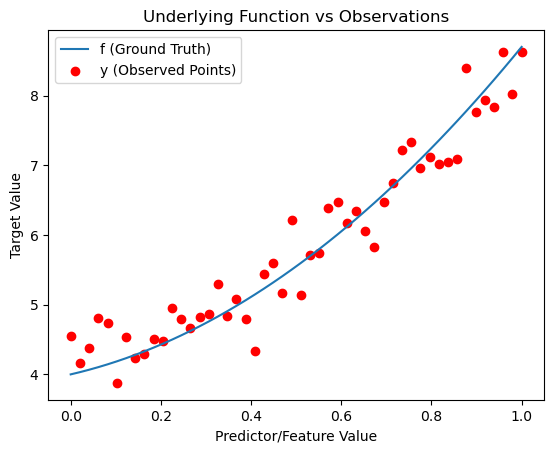

In [2]:
fig1 = plt.figure()
plt.plot(x, f, label = "f (Ground Truth)")
plt.scatter(x, y, label = "y (Observed Points)", color = "red")
plt.xlabel("Predictor/Feature Value")
plt.ylabel("Target Value")
plt.title("Underlying Function vs Observations")

plt.legend(loc="upper left")
plt.show()

## Your task is to implement the bias-variance decomposition of KNN using the simulated data set.

You may choose two or more values for $K$, such as 1 and 50, and see how the bias and variance values look like for different values of $K$. Remember the following:

$$\text{Expected Prediction Error (EPE)} = \text{Var}(\hat f(x_0))+ [\text{Bias}(\hat f(x_0))]^2 + \text{Var}(\varepsilon)$$

### Calculate the bias and variance with 1NN

In [3]:
from sklearn import neighbors

# Choose one specific x0
x_0 = np.array([[x[25]]])

# True target value
f_x_0 = f[25]

# Fit a 1-NN model
n_neighbors = 1
knn = neighbors.KNeighborsRegressor(n_neighbors, weights='uniform')

# Generate the predictions with 1-NN with the input x_0
# Why use f not y here?
E_f_x0_hat = knn.fit(x.reshape(-1, 1), f.reshape(-1, 1)).predict(x_0)

# Calculate bias with vector x0 
bias_x_0_k1 = f_x_0 - E_f_x0_hat.item()

# Calculate variance with vector x0 
var_x_0_k1 = sigma2 / n_neighbors

print(f"Bias at x0 (k=1): {bias_x_0_k1}")
print(f"Variance at x0 (k=1): {var_x_0_k1}")

Bias at x0 (k=1): 0.0
Variance at x0 (k=1): 0.1


### Calculate the bias and variance with 50NN

In [4]:
# Fit a 50-NN model
n_neighbors = 50
knn = neighbors.KNeighborsRegressor(n_neighbors, weights='uniform')

# Generate the predictions with 50-NN with the input x_0
E_f_x0_hat = knn.fit(x.reshape(-1, 1), f.reshape(-1, 1)).predict(x_0)

# Calculate bias with vector x0 
bias_x_0_k50 = f_x_0 - E_f_x0_hat.item()

# Calculate variance with vector x0 
var_x_0_k50 = sigma2 / n_neighbors

print(f"Bias at x0 (k=50): {bias_x_0_k50}")
print(f"Variance at x0 (k=50): {var_x_0_k50}")

Bias at x0 (k=50): -0.229258642232403
Variance at x0 (k=50): 0.002


- For a potential overfitting model, e.g. 1NN, the bias is 0, while the variance is high at 0.1.
- For a potential underfitting model, e.g. 50NN, the bias is high at -0.2293, while the variance is low at 0.002.
- Try to write a for loop to iterate through a range K values, and visualize the bias and varianc pattern VS K.